c:\Users\gaurav\anaconda3\envs\ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Fetching real UCI Taiwan Loan dataset via scikit-learn OpenML...

--- Initiating Hyperparameter Tuning (GridSearch with 3-Fold CV) ---
Tuning Monotonic XGBoost...
Training PyTorch ANN...
Training TensorFlow Lattice...
Training Official PyKAN...
checkpoint directory created: ./model
saving model version 0.0
Tuning Random Forest...
Tuning Decision Tree...
Tuning Standard XGBoost...

Calculating Predictive Metrics on Test Set...

Running Global Stability Evaluation on 100 Test Instances...
Processed 10/100 instances...
Processed 20/100 instances...
Processed 30/100 instances...
Processed 40/100 instances...
Processed 50/100 instances...
Processed 60/100 instances...
Processed 70/100 instances...
Processed 80/100 instances...
Processed 90/100 instances...
Processed 100/100 instances...

DATA POINTS WHERE JAAKKOLA'S METHOD COMPLETELY FAILED
(No neighbors found within Max Epsilon = 3.0 std devs)
Eval Instance Index: 0 | Original Test Set Index: 1782
Eval Instance Index: 1 | Original Test Se

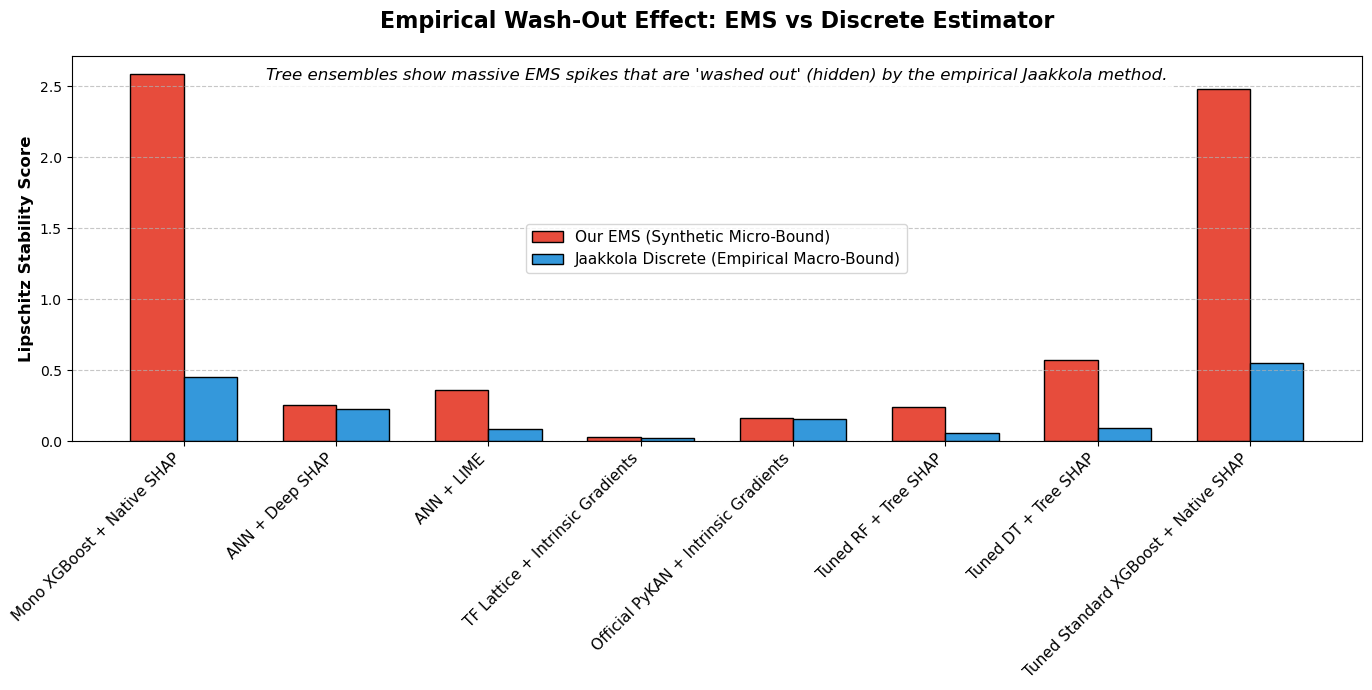

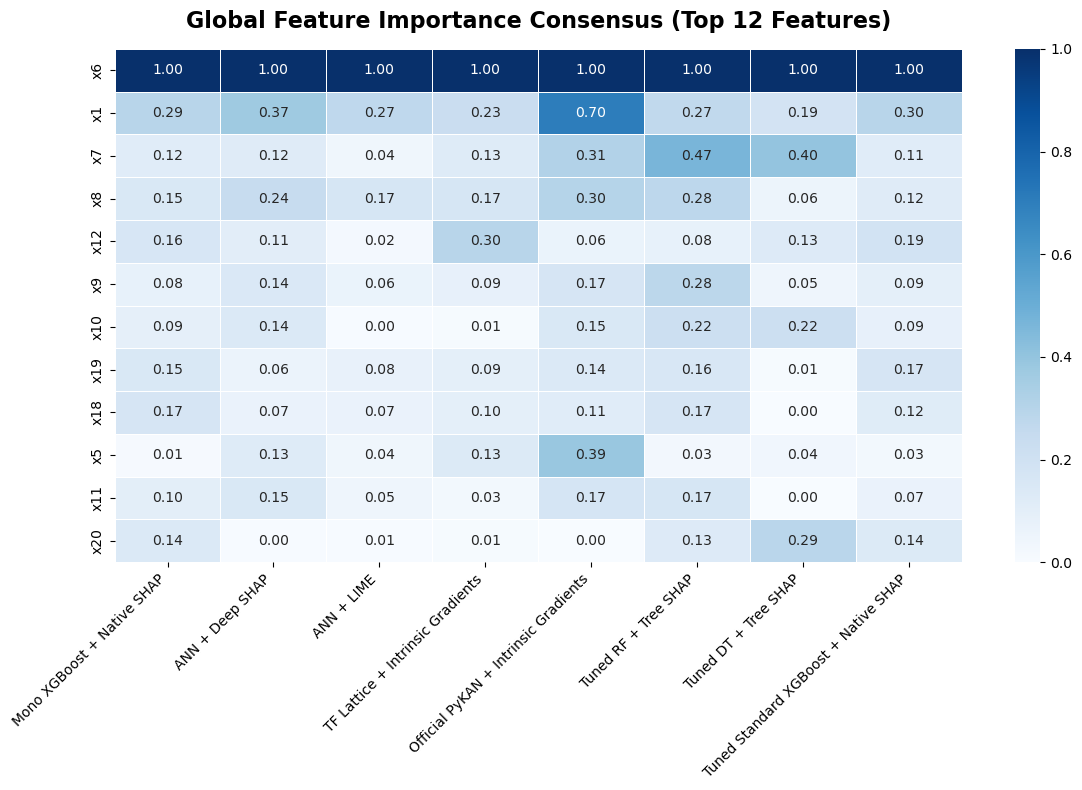

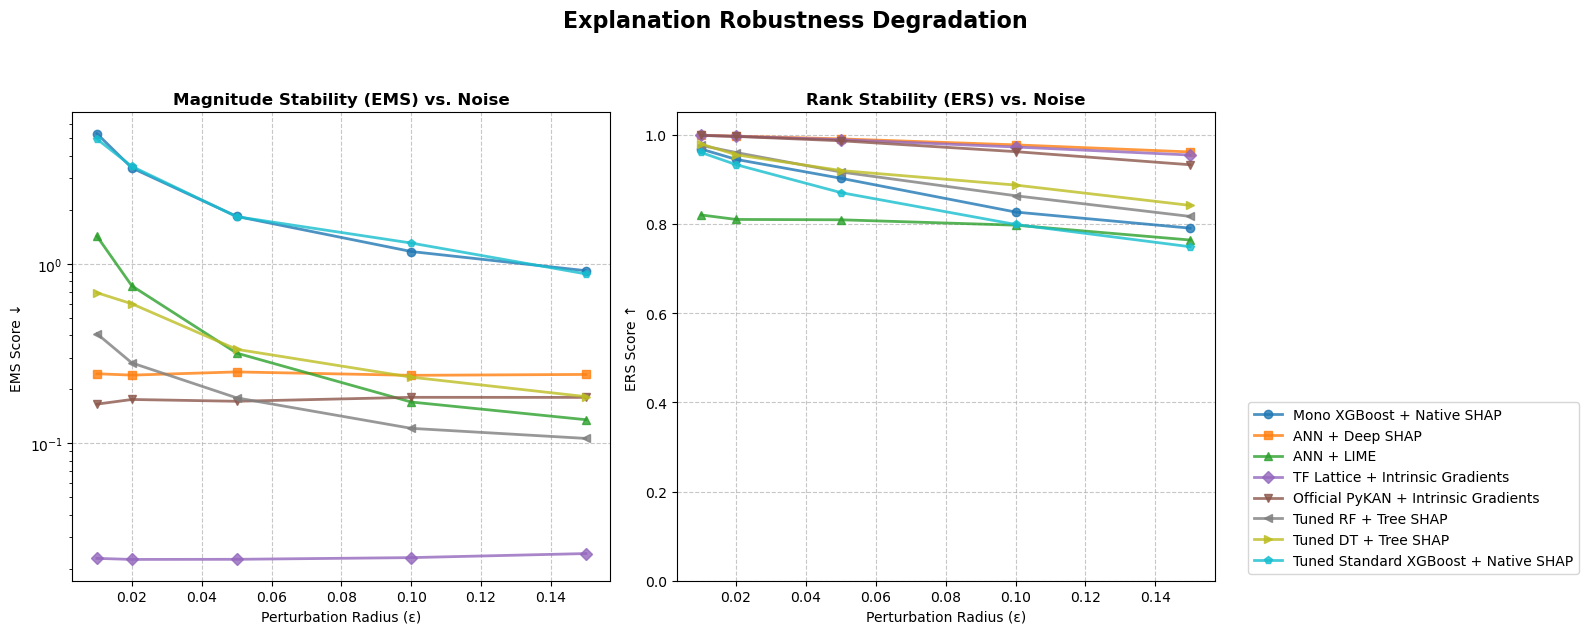

In [ ]:
import os
# This MUST be set before importing tensorflow to ensure TF Lattice (Keras 2) works
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from scipy.spatial.distance import cdist
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error, log_loss
import xgboost as xgb
import shap
import lime
import lime.lime_tabular
import torch
import torch.nn as nn
import torch.optim as optim
import tensorflow as tf
import tensorflow_lattice as tfl
from kan import KAN  # Official PyKAN Library
import warnings
import matplotlib.pyplot as plt
import re
import seaborn as sns

# Suppress warnings for cleaner output during execution
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

# ==========================================
# 0. GLOBAL EXPERIMENT HYPERPARAMETERS
# ==========================================
EPSILON = 0.05              # Perturbation radius (e.g., 0.05 = 5% shift relative to feature variance)
K_PERTURBATIONS = 100      # Size of the synthetic neighborhood 
N_EVAL_SAMPLES = 50         # Number of test set instances to evaluate stability on 
CV_FOLDS = 3                # Number of folds for Hyperparameter GridSearch
JAAK_MAX_EPSILON = 3.0      # Maximum expansion radius for the dynamic discrete search

# ==========================================
# 1. FETCH AND PREPARE REAL UCI DATA
# ==========================================
print("Fetching real UCI Taiwan Loan dataset via scikit-learn OpenML...")
dataset = fetch_openml(data_id=42477, as_frame=True, parser='auto')
df = dataset.frame

target_col = dataset.target_names[0]
X = df.drop(columns=[target_col]).values.astype(np.float32)
y = df[target_col].values.astype(int)
feature_names = df.drop(columns=[target_col]).columns.tolist()

# Indices of continuous features (categorical features will be frozen)
continuous_indices = [0, 4, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
feature_stds = X_train_scaled.std(axis=0)

# ==========================================
# 2. STABILITY METRICS & PERTURBATION
# ==========================================
def generate_tabular_perturbations(x, feature_stds, continuous_indices, epsilon, k):
    """Generates the Constraint-Aware Tabular Neighborhood."""
    x_perturbed = np.tile(x, (k, 1)).astype(float)
    for idx in continuous_indices:
        noise = np.random.normal(0, epsilon * feature_stds[idx], k)
        x_perturbed[:, idx] += noise
    return x_perturbed

def calculate_ems(x, x_perturbed, exp_x, exp_perturbed):
    dist_x = np.linalg.norm(x_perturbed - x, axis=1) + 1e-9 
    dist_exp = np.linalg.norm(exp_perturbed - exp_x, axis=1)
    return np.max(dist_exp / dist_x)

def calculate_ers(exp_x, exp_perturbed):
    base_rank = np.argsort(np.argsort(exp_x.flatten()))
    correlations = []
    for i in range(exp_perturbed.shape[0]):
        pert_rank = np.argsort(np.argsort(exp_perturbed[i].flatten()))
        corr, _ = spearmanr(base_rank, pert_rank)
        correlations.append(0.0 if np.isnan(corr) else corr)
    return np.mean(correlations)

def calculate_jaakkola_dynamic(x_instance, X_test_scaled, model_explainer_fn, start_epsilon=0.05, max_epsilon=3.0):
    """
    Dynamically expands the search radius until an empirical neighbor is found.
    Returns: (Lipschitz Score, Minimum Radius Required, Number of Neighbors Found)
    """
    distances = cdist(x_instance, X_test_scaled, metric='euclidean')[0]
    current_eps = start_epsilon
    
    while current_eps <= max_epsilon:
        valid_mask = (distances > 0) & (distances <= current_eps)
        neighbor_indices = np.where(valid_mask)[0]
        
        if len(neighbor_indices) > 0:
            valid_neighbors = X_test_scaled[neighbor_indices]
            valid_distances = distances[neighbor_indices]
            
            exp_x = model_explainer_fn(x_instance)
            exp_neighbors = model_explainer_fn(valid_neighbors)
            
            dist_exp = np.linalg.norm(exp_neighbors - exp_x, axis=1)
            quotients = dist_exp / valid_distances
            
            return np.max(quotients), current_eps, len(neighbor_indices)
            
        current_eps *= 2.0 
        
    return np.nan, np.nan, 0

def evaluate_instance_stability(x, model_explainer_fn, feature_stds, continuous_indices, epsilon, k, X_reference):
    exp_x = model_explainer_fn(x) 
    
    # 1. Constraint-Aware Synthetic Perturbation (Our EMS/ERS)
    x_perturbed = generate_tabular_perturbations(x, feature_stds, continuous_indices, epsilon, k)
    exp_perturbed = model_explainer_fn(x_perturbed)
    
    ems_score = calculate_ems(x, x_perturbed, exp_x, exp_perturbed)
    ers_score = calculate_ers(exp_x, exp_perturbed)
    
    # 2. Dynamic Jaakkola Search
    jaak_score, req_radius, n_neighbors = calculate_jaakkola_dynamic(
        x, X_reference, model_explainer_fn, start_epsilon=epsilon, max_epsilon=JAAK_MAX_EPSILON
    )
    
    return ems_score, ers_score, jaak_score, req_radius, n_neighbors

# ==========================================
# 3. TRAIN MODELS AND BUILD WRAPPERS
# ==========================================
constraints = tuple([-1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, -1, -1, -1, -1, -1, -1])
cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

print(f"\n--- Initiating Hyperparameter Tuning (GridSearch with {CV_FOLDS}-Fold CV) ---")

print("Tuning Monotonic XGBoost...")
xgb_mono_base = xgb.XGBClassifier(monotone_constraints=constraints, random_state=42, eval_metric='logloss')
param_grid_xgb = {'n_estimators': [50, 100], 'max_depth': [3, 6], 'learning_rate': [0.05, 0.1]}
xgb_mono_grid = GridSearchCV(xgb_mono_base, param_grid_xgb, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
xgb_mono_grid.fit(X_train_scaled, y_train)
xgb_mono = xgb_mono_grid.best_estimator_

def xgb_mono_shap_wrapper(X_input):
    contribs = xgb_mono.get_booster().predict(xgb.DMatrix(X_input), pred_contribs=True)
    return contribs[:, :-1]

print("Training PyTorch ANN...")
class CreditANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(X.shape[1], 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x): return self.fc(x)

ann_model = CreditANN()
optimizer = optim.Adam(ann_model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
ann_model.train()
for epoch in range(50):
    optimizer.zero_grad()
    loss = criterion(ann_model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer.step()
ann_model.eval()

deep_explainer = shap.DeepExplainer(ann_model, torch.tensor(X_train_scaled[:200], dtype=torch.float32))

def ann_shap_wrapper(X_input):
    shap_values = deep_explainer.shap_values(torch.tensor(X_input, dtype=torch.float32))
    if isinstance(shap_values, list): return np.array(shap_values[-1])
    shap_array = np.array(shap_values)
    if len(shap_array.shape) == 3: return shap_array[:, :, -1] 
    return shap_array

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled, feature_names=feature_names,
    class_names=['No Default', 'Default'], mode='classification', random_state=42
)

def ann_predict_proba(X_numpy):
    with torch.no_grad():
        probs_class_1 = torch.sigmoid(ann_model(torch.tensor(X_numpy, dtype=torch.float32))).squeeze().numpy()
        probs_class_0 = 1.0 - probs_class_1
    if probs_class_1.ndim == 0: return np.array([[probs_class_0, probs_class_1]])
    return np.vstack((probs_class_0, probs_class_1)).T

def ann_lime_wrapper(X_input):
    n_instances, n_feats = X_input.shape
    lime_exps = np.zeros((n_instances, n_feats))
    for i in range(n_instances):
        exp = lime_explainer.explain_instance(X_input[i], ann_predict_proba, num_features=n_feats)
        for feature_idx, weight in exp.as_map()[1]: lime_exps[i, feature_idx] = weight
    return lime_exps

print("Training TensorFlow Lattice...")
class TFLatticeModel(tf.keras.Model):
    def __init__(self, num_features, model_constraints):
        super(TFLatticeModel, self).__init__()
        self.tfl_linear = tfl.layers.Linear(num_input_dims=num_features, monotonicities=model_constraints)
        self.sigmoid = tf.keras.layers.Activation('sigmoid')
    def call(self, inputs): return self.sigmoid(self.tfl_linear(inputs))

tfl_model = TFLatticeModel(X.shape[1], constraints)
tfl_model.compile(optimizer='adam', loss='binary_crossentropy')
tfl_model.build(input_shape=(None, X.shape[1])) 
tfl_model.fit(X_train_scaled, y_train, epochs=20, verbose=0)

def tf_lattice_wrapper(X_input):
    X_tensor = tf.convert_to_tensor(X_input, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        preds = tfl_model(X_tensor)
    return (tape.gradient(preds, X_tensor) * X_tensor).numpy()

print("Training Official PyKAN...")
kan_model = KAN(width=[X.shape[1], 8, 1], grid=3, k=3, seed=42)
optimizer_kan = optim.Adam(kan_model.parameters(), lr=0.01)

kan_model.train()
for epoch in range(50):
    optimizer_kan.zero_grad()
    loss = criterion(kan_model(X_train_tensor), y_train_tensor)
    loss.backward()
    optimizer_kan.step()
kan_model.eval()

def kan_intrinsic_wrapper(X_input):
    X_tensor = torch.tensor(X_input, dtype=torch.float32, requires_grad=True)
    preds = kan_model(X_tensor)
    preds.sum().backward()
    attributions = (X_tensor.grad * X_tensor).detach().numpy()
    return attributions

print("Tuning Random Forest...")
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
param_grid_rf = {'n_estimators': [50, 100, 150], 'max_depth': [5, 10, 15]}
rf_grid = GridSearchCV(rf_base, param_grid_rf, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
rf_model = rf_grid.best_estimator_
rf_explainer = shap.TreeExplainer(rf_model)

def rf_shap_wrapper(X_input):
    sv = rf_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

print("Tuning Decision Tree...")
dt_base = DecisionTreeClassifier(random_state=42)
param_grid_dt = {'max_depth': [5, 10, 15], 'min_samples_split': [10, 20]}
dt_grid = GridSearchCV(dt_base, param_grid_dt, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
dt_grid.fit(X_train_scaled, y_train)
dt_model = dt_grid.best_estimator_
dt_explainer = shap.TreeExplainer(dt_model)

def dt_shap_wrapper(X_input):
    sv = dt_explainer.shap_values(X_input)
    if isinstance(sv, list): return np.array(sv[1])
    if len(sv.shape) == 3: return sv[:, :, 1]
    return sv

print("Tuning Standard XGBoost...")
xgb_std_base = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_std_grid = GridSearchCV(xgb_std_base, param_grid_xgb, cv=cv_strategy, scoring='neg_log_loss', n_jobs=-1)
xgb_std_grid.fit(X_train_scaled, y_train)
xgb_std = xgb_std_grid.best_estimator_

def xgb_std_shap_wrapper(X_input):
    contribs = xgb_std.get_booster().predict(xgb.DMatrix(X_input), pred_contribs=True)
    return contribs[:, :-1]

# ==========================================
# 4. PREDICTIVE PERFORMANCE EVALUATION
# ==========================================
print("\nCalculating Predictive Metrics on Test Set...")
predictive_metrics = {}

def get_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_prob)),
    }

prob_mono = xgb_mono.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Mono XGBoost + Native SHAP"] = get_metrics(y_test, prob_mono)

with torch.no_grad():
    prob_ann = torch.sigmoid(ann_model(torch.tensor(X_test_scaled, dtype=torch.float32))).squeeze().numpy()
predictive_metrics["ANN + Deep SHAP"] = get_metrics(y_test, prob_ann)
predictive_metrics["ANN + LIME"] = get_metrics(y_test, prob_ann)

prob_tfl = tfl_model(tf.convert_to_tensor(X_test_scaled, dtype=tf.float32)).numpy().squeeze()
predictive_metrics["TF Lattice + Intrinsic Gradients"] = get_metrics(y_test, prob_tfl)

with torch.no_grad():
    prob_kan = torch.sigmoid(kan_model(torch.tensor(X_test_scaled, dtype=torch.float32))).squeeze().numpy()
predictive_metrics["Official PyKAN + Intrinsic Gradients"] = get_metrics(y_test, prob_kan)

prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Tuned RF + Tree SHAP"] = get_metrics(y_test, prob_rf)

prob_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Tuned DT + Tree SHAP"] = get_metrics(y_test, prob_dt)

prob_xgb_std = xgb_std.predict_proba(X_test_scaled)[:, 1]
predictive_metrics["Tuned Standard XGBoost + Native SHAP"] = get_metrics(y_test, prob_xgb_std)

# ==========================================
# 5. GLOBAL STABILITY EVALUATION LOOP
# ==========================================
np.random.seed(42)
eval_indices = np.random.choice(len(X_test_scaled), N_EVAL_SAMPLES, replace=False)
X_eval = X_test_scaled[eval_indices]

wrappers = {
    "Mono XGBoost + Native SHAP": xgb_mono_shap_wrapper,
    "ANN + Deep SHAP": ann_shap_wrapper,
    "ANN + LIME": ann_lime_wrapper,
    "TF Lattice + Intrinsic Gradients": tf_lattice_wrapper,
    "Official PyKAN + Intrinsic Gradients": kan_intrinsic_wrapper,
    "Tuned RF + Tree SHAP": rf_shap_wrapper,
    "Tuned DT + Tree SHAP": dt_shap_wrapper,
    "Tuned Standard XGBoost + Native SHAP": xgb_std_shap_wrapper
}

print(f"\nRunning Global Stability Evaluation on {N_EVAL_SAMPLES} Test Instances...")

results_dict = {name: {"ems": [], "ers": [], "jaakkola": [], "jaak_radius": [], "jaak_neighbors": []} for name in wrappers.keys()}
failed_jaakkola_indices = set()

for i in range(N_EVAL_SAMPLES):
    x_instance = X_eval[i:i+1]
    if (i + 1) % 10 == 0: print(f"Processed {i + 1}/{N_EVAL_SAMPLES} instances...")
        
    for model_name, wrapper_fn in wrappers.items():
        try:
            ems, ers, jaakkola, req_radius, n_neighbors = evaluate_instance_stability(
                x=x_instance, 
                model_explainer_fn=wrapper_fn,
                feature_stds=feature_stds, 
                continuous_indices=continuous_indices,
                epsilon=EPSILON,          
                k=K_PERTURBATIONS,
                X_reference=X_test_scaled
            )
            results_dict[model_name]["ems"].append(ems)
            results_dict[model_name]["ers"].append(ers)
            results_dict[model_name]["jaakkola"].append(jaakkola)
            results_dict[model_name]["jaak_radius"].append(req_radius)
            results_dict[model_name]["jaak_neighbors"].append(n_neighbors)
            
            if np.isnan(jaakkola):
                failed_jaakkola_indices.add((i, eval_indices[i])) # Store loop index and original dataset index
                
        except Exception as e:
            pass 

print("\n" + "="*80)
print("DATA POINTS WHERE JAAKKOLA'S METHOD COMPLETELY FAILED")
print(f"(No neighbors found within Max Epsilon = {JAAK_MAX_EPSILON} std devs)")
print("="*80)
if not failed_jaakkola_indices:
    print("None! Jaakkola's method found at least one neighbor for all points at expanded radii.")
else:
    for eval_idx, orig_idx in sorted(failed_jaakkola_indices):
        print(f"Eval Instance Index: {eval_idx} | Original Test Set Index: {orig_idx}")

# ==========================================
# 6. COMPILE AND EXPORT RESULTS
# ==========================================
final_results = []
for model_name, metrics in results_dict.items():
    ems_list, ers_list, jaak_list, radius_list, neighbors_list = metrics["ems"], metrics["ers"], metrics["jaakkola"], metrics["jaak_radius"], metrics["jaak_neighbors"]
    pred_mets = predictive_metrics[model_name]
    
    valid_jaak = [j for j in jaak_list if not np.isnan(j)]
    valid_radius = [r for r in radius_list if not np.isnan(r)]
    
    jaak_mean = np.nanmean(valid_jaak) if valid_jaak else np.nan
    radius_mean = np.nanmean(valid_radius) if valid_radius else np.nan
    avg_neighbors = np.mean(neighbors_list) if neighbors_list else 0
    jaak_fail_rate = (1.0 - (len(valid_jaak) / len(jaak_list))) * 100 if jaak_list else 100
    
    if ems_list and ers_list:
        final_results.append({
            "Model / Explainer": model_name,
            "Accuracy ↑": f"{pred_mets['Accuracy']:.4f}",
            "Jaak. Fail %": f"{jaak_fail_rate:.1f}%",
            "Avg. Neighbors Found": f"{avg_neighbors:.1f}",
            "Jaak. Min Radius": f"{radius_mean:.3f}" if not np.isnan(radius_mean) else "N/A",
            "Jaak. Score ↓": f"{jaak_mean:.4f}" if not np.isnan(jaak_mean) else "FAILED",
            "Our EMS ↓": f"{np.mean(ems_list):.4f}",
            "Our ERS ↑": f"{np.mean(ers_list):.4f}"
        })

results_df = pd.DataFrame(final_results)
results_df.to_csv("comprehensive_benchmark_results.csv", index=False)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n" + "="*140)
print("FINAL COMPREHENSIVE BENCHMARK RESULTS (PROVING EMPIRICAL WASH-OUT)")
print("="*140)
print(results_df.to_string(index=False))
print("="*140)

# ==========================================
# 7. VISUALIZATIONS
# ==========================================
print("\nExecuting Visualizations...")

def parse_val(data_str):
    try: return float(data_str)
    except: return 0.0

# --- 7A. The "Wash-Out" Visual Comparison (EMS vs Jaakkola) ---
def generate_washout_comparison_viz(results_df, output_path='washout_comparison_chart.png'):
    model_labels = results_df["Model / Explainer"].tolist()
    
    ems_means = results_df["Our EMS ↓"].apply(parse_val).tolist()
    jaak_means = results_df["Jaak. Score ↓"].apply(parse_val).tolist()
    
    x = np.arange(len(model_labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(14, 7))
    rects1 = ax.bar(x - width/2, ems_means, width, label='Our EMS (Synthetic Micro-Bound)', color='#E74C3C', edgecolor='black')
    rects2 = ax.bar(x + width/2, jaak_means, width, label='Jaakkola Discrete (Empirical Macro-Bound)', color='#3498DB', edgecolor='black')

    ax.set_ylabel('Lipschitz Stability Score', fontsize=12, fontweight='bold')
    ax.set_title('Empirical Wash-Out Effect: EMS vs Discrete Estimator', fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=45, ha='right', fontsize=11)
    ax.legend(fontsize=11)
    
    # Adding text to emphasize washed out scores
    plt.text(0.5, 0.95, "Tree ensembles show massive EMS spikes that are 'washed out' (hidden) by the empirical Jaakkola method.", 
             horizontalalignment='center', verticalalignment='center', transform=ax.transAxes, 
             fontsize=12, style='italic', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')

generate_washout_comparison_viz(results_df)

# --- 7B. Feature Consensus Heatmap ---
global_importance = {}
for model_name, wrapper_fn in wrappers.items():
    try:
        base_exps = wrapper_fn(X_eval)
        mean_abs_attr = np.mean(np.abs(base_exps), axis=0)
        min_val, max_val = np.min(mean_abs_attr), np.max(mean_abs_attr)
        global_importance[model_name] = (mean_abs_attr - min_val) / (max_val - min_val) if max_val > min_val else mean_abs_attr
    except Exception: pass

importance_df = pd.DataFrame(global_importance, index=feature_names)
importance_df['Avg_Imp'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values(by='Avg_Imp', ascending=False).drop(columns=['Avg_Imp']).head(12)

plt.figure(figsize=(12, 8))
sns.heatmap(importance_df, cmap="Blues", annot=True, fmt=".2f", linewidths=.5)
plt.title("Global Feature Importance Consensus (Top 12 Features)", fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_agreement_heatmap.png', dpi=300)

# --- 7C. Epsilon Degradation Curves (Using EMS/ERS) ---
epsilon_range = [0.01, 0.02, 0.05, 0.10 ]         
N_DEG_SAMPLES = 20
X_deg = X_test_scaled[np.random.choice(len(X_test_scaled), N_DEG_SAMPLES, replace=False)]

degradation_ems, degradation_ers = {name: [] for name in wrappers.keys()}, {name: [] for name in wrappers.keys()}

for eps in epsilon_range:
    for model_name, wrapper_fn in wrappers.items():
        ems_scores, ers_scores = [], []
        for i in range(N_DEG_SAMPLES):
            try:
                ems, ers, _, _, _ = evaluate_instance_stability(
                    x=X_deg[i:i+1], model_explainer_fn=wrapper_fn, feature_stds=feature_stds, 
                    continuous_indices=continuous_indices, epsilon=eps, k=50, X_reference=X_test_scaled
                )
                ems_scores.append(ems); ers_scores.append(ers)
            except Exception: pass
        degradation_ems[model_name].append(np.mean(ems_scores) if ems_scores else 0)
        degradation_ers[model_name].append(np.mean(ers_scores) if ers_scores else 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, len(wrappers)))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

for idx, model_name in enumerate(wrappers.keys()):
    ax1.plot(epsilon_range, degradation_ems[model_name], marker=markers[idx], color=colors[idx], label=model_name, linewidth=2, alpha=0.8)
    ax2.plot(epsilon_range, degradation_ers[model_name], marker=markers[idx], color=colors[idx], label=model_name, linewidth=2, alpha=0.8)

ax1.set_title('Magnitude Stability (EMS) vs. Noise', fontweight='bold')
ax1.set_xlabel('Perturbation Radius (ε)')
ax1.set_ylabel('EMS Score ↓')
ax1.set_yscale('log')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.set_title('Rank Stability (ERS) vs. Noise', fontweight='bold')
ax2.set_xlabel('Perturbation Radius (ε)')
ax2.set_ylabel('ERS Score ↑')
ax2.set_ylim(0, 1.05)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(bbox_to_anchor=(1.05, 0), loc='lower left')

plt.suptitle('Explanation Robustness Degradation', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('epsilon_degradation_curves.png', dpi=300)

print("\nAll scripts completed successfully. Visualizations saved.")